# Precision dt jax 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from solvers.runge_kutta import RK_tableaux, RK_solver_fixed
import jax
import jax.numpy as jnp


In [2]:
# Enable 64-bit precision in JAX
jax.config.update("jax_enable_x64", True)

In [9]:
key = jax.random.PRNGKey(0)
x_rand = jax.random.normal(key) * 20.0
x_rand

Array(-15.69531553, dtype=float64)

When enabled, default is float64

### Pendulum

In [3]:
def F_pendulum(x,t):
    return jnp.array([x[1], -((2*jnp.pi/12)**2)* jnp.sin(x[0]) - 0.2*x[1]], dtype=jnp.float64)

In [4]:
y0 = jnp.array([1.0,1.0], dtype=jnp.float64)
y0

Array([1., 1.], dtype=float64)

In [6]:
y0 = jnp.array([1.0,1.0]).astype(jnp.float64)
t0=0
t1=10
dt_ref = 0.00001
num_steps = int((t1-t0)/dt_ref)
traj_ref, _,_,_ = RK_solver_fixed(F_pendulum, y0, dt_ref, num_steps, RK_tableaux['RK4'])
final_val_ref = traj_ref[:,-1]

[-0.90709305 -0.16965328]
error 0.17185439672489206 dt 0.25 t_final 10.0
error 5.979829628874851e-06 dt 0.125 t_final 10.0
error 3.756371762836848e-07 dt 0.0625 t_final 10.0
error 2.3505702799301936e-08 dt 0.03125 t_final 10.0
error 1.4690116979077953e-09 dt 0.015625 t_final 10.0
error 9.168840340392503e-11 dt 0.0078125 t_final 10.0
error 5.698739257558594e-12 dt 0.00390625 t_final 10.0
error 3.538536988916053e-13 dt 0.001953125 t_final 10.0
error 2.938318027221467e-14 dt 0.0009765625 t_final 10.0
error 8.888720382515246e-15 dt 0.00048828125 t_final 10.0
error 1.2994827337208943e-14 dt 0.000244140625 t_final 10.0
error 1.9535509074604446e-14 dt 0.0001220703125 t_final 10.0
error 4.8954289415806065e-14 dt 6.103515625e-05 t_final 10.0
error 5.247492350911142e-15 dt 3.0517578125e-05 t_final 10.0
error 4.592433213462841e-14 dt 1.52587890625e-05 t_final 10.0


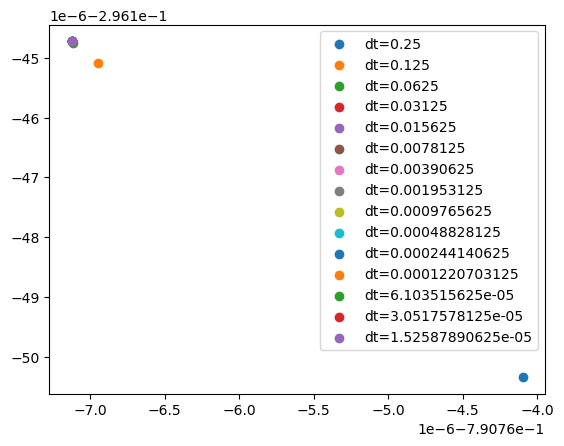

In [4]:
y0 = jnp.array([1.0,1.0])
dt = 0.5
t0=0
t1=10
num_steps = int((t1-t0)/dt)+dt
traj,_,_,_ = RK_solver_fixed(F_pendulum, y0, dt, num_steps, RK_tableaux['RK4'])
#plt.scatter(traj[0,-1], traj[1,-1], label=f"dt={dt}")
yold = traj[:,-1]
print(yold)
y_list = [yold]
errors =[]
for k in range(15):
    # update params
    dt = dt/2
    num_steps = int((t1-t0)/dt)
    traj,_,_,_ = RK_solver_fixed(F_pendulum, y0, dt, num_steps, RK_tableaux['RK4'])
    ynext = traj[:,-1]
    #print("t_final", (traj.shape[1]-1)*dt)
    print("error", jnp.linalg.norm(ynext - yold),"dt", dt,"t_final", (traj.shape[1]-1)*dt)
    errors.append(jnp.linalg.norm(ynext - yold))
    yold = ynext
    y_list.append(yold)
    plt.scatter(traj[0,-1], traj[1,-1], label=f"dt={dt}")
    

plt.legend()


Text(0, 0.5, 'error')

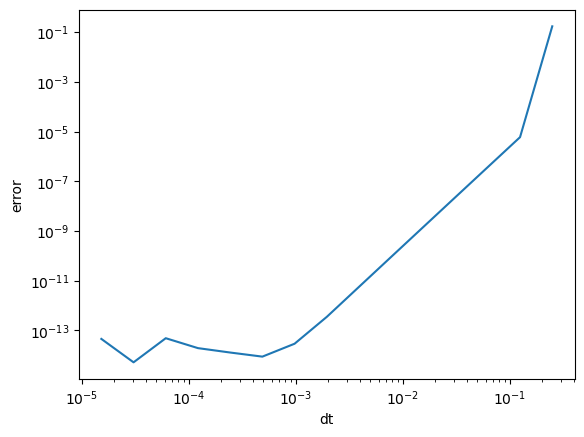

In [5]:
dt_list = jnp.array([0.5/2**k for k in range(1,len(errors)+1)])
plt.plot(dt_list, errors)
plt.yscale('log')
plt.xscale('log')
plt.xlabel("dt")
plt.ylabel("error")

# CCL: Il faut passer en float64